# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [1]:
# Get the datasets
!!/usr/bin/curl --output test.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/test_small.txt
!!/usr/bin/curl --output train.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/train.txt


['  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current',
 '                                 Dload  Upload   Total   Spent    Left  Speed',
 '',
 '  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0',
 '100 11645  100 11645    0     0  52902      0 --:--:-- --:--:-- --:--:-- 52931']

In [2]:
# Take a peek at the datasets
!head train.dat
!head test.dat

A1	A2	A3	A4	A5	A6	A7	A8	A9	A10	A11	A12	A13	
1	1	0	0	0	0	0	0	1	1	0	0	1	0
0	0	1	1	0	1	1	0	0	0	0	0	1	0
0	1	0	1	1	0	1	0	1	1	1	0	1	1
0	0	1	0	0	1	0	1	0	1	1	1	1	0
0	1	0	0	0	0	0	1	1	1	1	1	1	0
0	1	1	1	0	0	0	1	0	1	1	0	1	1
0	1	1	0	0	0	1	0	0	0	0	0	1	0
0	0	0	1	1	0	1	1	1	0	0	0	1	0
0	0	0	0	0	0	1	0	1	0	1	0	1	0
X1	X2	X3
1	1	1	1
0	0	1	1
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
1	1	1	1


### Build the Perceptron Model

You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [3]:
import math
import itertools
import re


# Corpus reader, all columns but the last one are coordinates;
#   the last column is the label
def read_data(file_name):
    f = open(file_name, 'r')

    data = []
    # Discard header line
    f.readline()
    for instance in f.readlines():
        if not re.search('\t', instance): continue
        instance = list(map(int, instance.strip().split('\t')))
        # Add a dummy input so that w0 becomes the bias
        instance = [-1] + instance
        data += [instance]
    return data


def dot_product(array1, array2):
    # Sum of (w_i * x_i)
    return sum(w * x for w, x in zip(array1, array2))



def sigmoid(x):
    return 1 / (1 + math.exp(-x))


# The output of the model, which for the perceptron is 
# the sigmoid function applied to the dot product of 
# the instance and the weights
def output(weight, instance):
    return sigmoid(dot_product(weight, instance))

# Predict the label of an instance; this is the definition of the perceptron
# you should output 1 if the output is >= 0.5 else output 0
def predict(weights, instance):
    # Threshold at 0.5
    return 1 if output(weights, instance) >= 0.5 else 0


# Accuracy = percent of correct predictions
def get_accuracy(weights, instances):
    # You do not to write code like this, but get used to it
    correct = sum([1 if predict(weights, instance) == instance[-1] else 0
                   for instance in instances])
    return correct * 100 / len(instances)


# Train a perceptron with instances and hyperparameters:
#       lr (learning rate) 
#       epochs
# The implementation comes from the definition of the perceptron
#
# Training consists on fitting the parameters which are the weights
# that's the only thing training is responsible to fit
# (recall that w0 is the bias, and w1..wn are the weights for each coordinate)
#
# Hyperparameters (lr and epochs) are given to the training algorithm
# We are updating weights in the opposite direction of the gradient of the error,
# so with a "decent" lr we are guaranteed to reduce the error after each iteration.
def train_perceptron(instances, lr, epochs):

    #TODO: name this step
    weights = [0] * (len(instances[0])-1)

    for _ in range(epochs):
        for instance in instances:
            # Step: Forward Pass (calculate prediction)
            in_value = dot_product(weights, instance)
            output = sigmoid(in_value)
            # Step: Calculate Error
            error = instance[-1] - output
            # Step: Weight Update (Backpropagation/Gradient Descent)
            for i in range(0, len(weights)):
                weights[i] += lr * error * output * (1-output) * instance[i]

    return weights

## Run it

In [4]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
lr = 0.005
epochs = 5
weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)
print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4


## Questions

Answer the following questions. Include your implementation and the output for each question.



### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)

The predict function is a non-differentiable step function that employs a hard threshold (0 or 1). It would be impossible to use Gradient Descent to update the weights if we used predict because the gradient would be zero almost everywhere. We obtain a differentiable (smooth) function by utilizing the sigmoid output. This enables us to determine the gradient of the error and precisely modify the weights according to the degree to which the prediction deviates from the actual label.


### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 


In [5]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]     # number of epochs
lr_array = [0.005, 0.01, 0.05]        # learning rate
results = []
for lr in lr_array:
  for tr_size in tr_percent:
    for epochs in num_epochs:
        size =  round(len(instances_tr)*tr_size/100)
        pre_instances = instances_tr[0:size]
        weights = train_perceptron(pre_instances, lr, epochs)
        accuracy = get_accuracy(weights, instances_te)
        
        results.append({
                'lr': lr, 
                'tr_size': tr_size, 
                'epochs': epochs, 
                'accuracy': accuracy
            })
        print(f"#tr: {len(pre_instances):0}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
            f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 20, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 40, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 40, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 40, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 40, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs:  20, learning rate: 

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
   ```
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
```
- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?

#### TODO: Add your answer here (code and text)



A-No, you don't. The results show that using smaller parts of the training data, like 5% or 10%, can sometimes get the highest test accuracy (85.7%). The test set is very small (only 14 instances), so smaller training datasets can sometimes work well without making the model too complicated. In contrast, the full dataset might make the model overfit.

B-This happens because of the hyperparameters, especially the learning rate. The second run has a learning rate that is much lower (0.005 instead of 0.050). The model probably hasn't had enough epochs to converge because the step size is too small. Also, adding more data changes the gradient landscape. A model with more data may need a different learning rate or more epochs to find the best weights than a model with less data.

Yes, for sure. The results already show that some combinations are 85.7% accurate (for instance, 20% data, 50 epochs, and a learning rate of 0.01). You might be able to get this even higher by changing the decision threshold, fine-tuning the learning rate even more, or adding learning rate decay.

D-No way. Training for too many epochs can cause overfitting, which is when the model remembers the training data but can't apply what it learned to new test data. You can see this clearly in the output: the accuracy goes up to 85.7% at 50 epochs when training with 20 instances and a 0.01 learning rate, but it goes down to 42.9% when forced to train for 100 epochs.

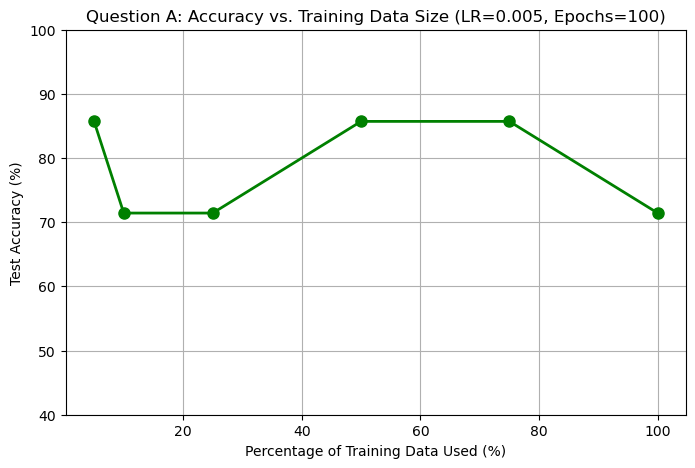

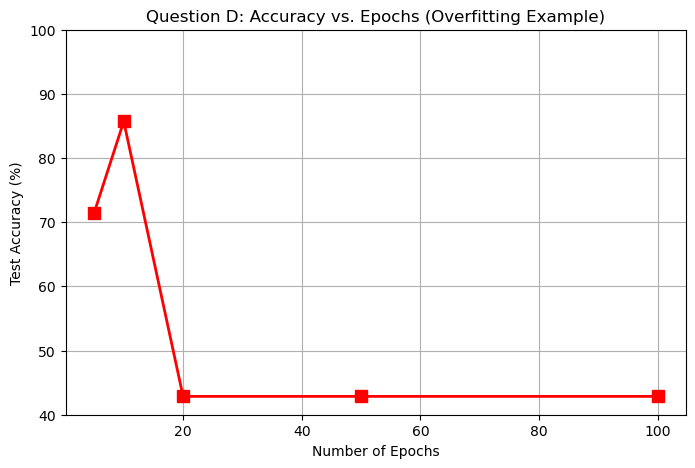

In [7]:
import matplotlib.pyplot as plt


# Plot 1: Accuracy vs Training Size (at fixed lr=0.05 and epochs=100)
plt.figure(figsize=(8, 5))
plot1_data = [r for r in results if r['lr'] == 0.005 and r['epochs'] == 100]

# Extracting x and y values
x1 = [r['tr_size'] for r in plot1_data] 
y1 = [r['accuracy'] for r in plot1_data]

plt.plot(x1, y1, marker='o', color='green', linewidth=2, markersize=8)
plt.title('Question A: Accuracy vs. Training Data Size (LR=0.005, Epochs=100)')
plt.xlabel('Percentage of Training Data Used (%)')
plt.ylabel('Test Accuracy (%)')
plt.ylim(40, 100)
plt.grid(True)
plt.show()

# Plot 2: Accuracy vs Epochs 
plt.figure(figsize=(8, 5))
plot2_data = [r for r in results if r['lr'] == 0.05 and r['tr_size'] == 5]

# Extracting x and y values
x2 = [r['epochs'] for r in plot2_data]
y2 = [r['accuracy'] for r in plot2_data]

plt.plot(x2, y2, marker='s', color='red', linewidth=2, markersize=8)
plt.title('Question D: Accuracy vs. Epochs (Overfitting Example)')
plt.xlabel('Number of Epochs')
plt.ylabel('Test Accuracy (%)')
plt.ylim(40, 100)
plt.grid(True)
plt.show()